<a href="https://colab.research.google.com/github/sebastianvettel1212/GrokkingDeepLearning/blob/main/04_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 4 — *Gradient Descent*: Pengantar Pembelajaran Neural Network (*Introduction to Neural Learning*)

**Buku:** *Grokking Deep Learning* — Andrew W. Trask (Manning, 2019)

Dua langkah berikutnya dari siklus belajar: ***compare*** (membandingkan prediksi dengan target) dan ***learn*** (memperbaiki bobot). *Gradient descent* adalah algoritma belajar terpenting dalam deep learning. Kode diambil dari repositori resmi buku, ditambah teori dan beberapa ilustrasi (berlabel *Tambahan*).

---

## Daftar Isi
1. *Compare*: Seberapa Baik Prediksi Kita? (MSE)
2. Bentuk Pembelajaran Paling Sederhana: *Hot and Cold Learning*
3. Menghitung Arah dan Besar Perubahan dari Error
4. Satu Iterasi *Gradient Descent*
5. Belajar = Mengurangi Error
6. Mengamati Beberapa Langkah Belajar
7. Apa Sebenarnya *weight_delta*? (*Derivative*)
8. Memakai *Derivative* untuk Belajar
9. Merusak *Gradient Descent*: *Overcorrection* dan *Alpha*
10. Ringkasan Bab

## 1. *Compare*: Seberapa Baik Prediksi Kita?

Setelah *predict*, kita perlu mengukur **seberapa salah** prediksi. Ukuran yang dipakai: ***mean squared error*** untuk satu data:
$$\text{error}=(\text{pred}-\text{goal})^2$$

**Mengapa dikuadratkan?**
1. Error selalu **positif** (kesalahan ke atas dan ke bawah tidak saling menghapus).
2. Kuadrat **memperbesar hukuman untuk kesalahan besar** dan memperkecil untuk kesalahan kecil, sehingga jaringan lebih fokus memperbaiki kesalahan besar dahulu.

In [1]:
knob_weight = 0.5
input = 0.5
goal_pred = 0.8

pred = input * knob_weight
error = (pred - goal_pred) ** 2
print(error)

0.30250000000000005


**Interpretasi:** prediksi $0{,}5\times0{,}5=0{,}25$, target 0,8, sehingga error $=(0{,}25-0{,}8)^2=0{,}3025$.

---
## 2. *Hot and Cold Learning*

Cara belajar paling sederhana: **coba geser bobot ke atas dan ke bawah sedikit, lihat arah mana error lebih kecil, lalu ikuti arah itu.**

Langkah: (1) jaringan awal, (2) *predict* dan hitung error, (3) coba bobot **lebih tinggi** dan hitung error, (4) coba bobot **lebih rendah** dan hitung error, lalu pilih arah yang error-nya lebih kecil.

In [2]:
# 1) An Empty Network

weight = 0.1
lr = 0.01

def neural_network(input, weight):
    prediction = input * weight
    return prediction


# 2) PREDICT: Making A Prediction And Evaluating Error

number_of_toes = [8.5]
win_or_lose_binary = [1] #(won!!!)

input = number_of_toes[0]
true = win_or_lose_binary[0]

pred = neural_network(input,weight)
error = (pred - true) ** 2
print(error)

0.022499999999999975


In [3]:
# 3) COMPARE: Making A Prediction With a *Higher* Weight And Evaluating Error

weight = 0.1

def neural_network(input, weight):
    prediction = input * weight
    return prediction

number_of_toes = [8.5]
win_or_lose_binary = [1] #(won!!!)

input = number_of_toes[0]
true = win_or_lose_binary[0]

lr = 0.01
p_up = neural_network(input,weight+lr)
e_up = (p_up - true) ** 2
print(e_up)

0.004224999999999993


In [4]:
# 4) COMPARE: Making A Prediction With a *Lower* Weight And Evaluating Error

weight = 0.1

def neural_network(input, weight):
    prediction = input * weight
    return prediction

number_of_toes = [8.5]
win_or_lose_binary = [1] #(won!!!)

input = number_of_toes[0]
true = win_or_lose_binary[0]

lr = 0.01
p_dn = neural_network(input,weight-lr)
e_dn = (p_dn - true) ** 2
print(e_dn)

0.05522499999999994


**Interpretasi:** error awal 0,0225; bobot dinaikkan → 0,004225 (**lebih kecil**); bobot diturunkan → 0,055225 (**lebih besar**). Jadi arah yang benar adalah **menaikkan** bobot.

### Hot and Cold Learning (loop penuh)
Mengulang proses itu terus-menerus. *(Kode buku mencetak setiap iterasi; di sini hanya setiap 100 iterasi agar keluaran ringkas.)*

In [5]:
weight = 0.5
input = 0.5
goal_prediction = 0.8

step_amount = 0.001

for iteration in range(1101):

    prediction = input * weight
    error = (prediction - goal_prediction) ** 2

    if iteration % 100 == 0 or iteration == 1100:
        print("Error:" + str(error) + " Prediction:" + str(prediction))

    up_prediction = input * (weight + step_amount)
    up_error = (goal_prediction - up_prediction) ** 2

    down_prediction = input * (weight - step_amount)
    down_error = (goal_prediction - down_prediction) ** 2

    if(down_error < up_error):
        weight = weight - step_amount

    if(down_error > up_error):
        weight = weight + step_amount

Error:0.30250000000000005 Prediction:0.25
Error:0.25 Prediction:0.30000000000000004
Error:0.20249999999999996 Prediction:0.3500000000000001
Error:0.15999999999999992 Prediction:0.40000000000000013
Error:0.1224999999999999 Prediction:0.4500000000000002
Error:0.0899999999999999 Prediction:0.5000000000000002
Error:0.06250000000000266 Prediction:0.5499999999999947
Error:0.04000000000000434 Prediction:0.5999999999999892
Error:0.0225000000000049 Prediction:0.6499999999999837
Error:0.01000000000000437 Prediction:0.6999999999999782
Error:0.0025000000000027357 Prediction:0.7499999999999727
Error:1.0799505792475652e-27 Prediction:0.7999999999999672


**Interpretasi:** prediksi perlahan mendekati 0,8 dan error menuju 0. **Kelemahan *hot and cold*:**
1. **Tidak efisien:** harus menghitung prediksi dua kali tiap langkah.
2. ***Step size* tetap:** langkahnya tidak peduli seberapa jauh dari target; tidak bisa mempercepat saat jauh atau memperhalus saat dekat (bisa "bergetar" di sekitar target).
3. Hanya tahu arah, tidak tahu **seberapa besar** harus bergerak.

---
## 3. Menghitung Arah dan Besar Perubahan dari Error

Solusi: hitung **arah dan besar** koreksi langsung dari error:
$$\text{direction\_and\_amount}=(\text{pred}-\text{goal})\times\text{input}$$
Lalu `weight = weight - direction_and_amount`. Besar koreksi mengikuti seberapa besar kesalahan (*delta*) dan seberapa besar input.

In [6]:
weight = 0.5
goal_pred = 0.8
input = 0.5

for iteration in range(20):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    direction_and_amount = (pred - goal_pred) * input
    weight = weight - direction_and_amount

    print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.30250000000000005 Prediction:0.25
Error:0.17015625000000004 Prediction:0.3875
Error:0.095712890625 Prediction:0.49062500000000003
Error:0.05383850097656251 Prediction:0.56796875
Error:0.03028415679931642 Prediction:0.6259765625
Error:0.0170348381996155 Prediction:0.669482421875
Error:0.00958209648728372 Prediction:0.70211181640625
Error:0.005389929274097089 Prediction:0.7265838623046875
Error:0.0030318352166796153 Prediction:0.7449378967285156
Error:0.0017054073093822882 Prediction:0.7587034225463867
Error:0.0009592916115275371 Prediction:0.76902756690979
Error:0.0005396015314842384 Prediction:0.7767706751823426
Error:0.000303525861459885 Prediction:0.7825780063867569
Error:0.00017073329707118678 Prediction:0.7869335047900676
Error:9.603747960254256e-05 Prediction:0.7902001285925507
Error:5.402108227642978e-05 Prediction:0.7926500964444131
Error:3.038685878049206e-05 Prediction:0.7944875723333098
Error:1.7092608064027242e-05 Prediction:0.7958656792499823
Error:9.614592036015323

**Interpretasi:** error turun cepat di awal (langkah besar saat jauh dari target) lalu melambat saat mendekati target. Tidak perlu lagi mencoba naik/turun.

### Efek *stopping*, *negative reversal*, dan *scaling*
Rumus `weight_delta = delta × input` memiliki tiga efek penting:
- ***Stopping*:** bila input = 0, `weight_delta` = 0 → bobot tidak berubah (input 0 tidak memberi informasi).
- ***Negative reversal*:** bila input negatif, arah koreksi **terbalik**, sehingga bobot tetap bergerak ke arah yang benar.
- ***Scaling*:** input yang lebih besar → koreksi lebih besar (bisa berbahaya; lihat bagian 9).

In [7]:
# Tambahan (tidak ada di buku): efek stopping, negative reversal, scaling pada weight_delta
weight, goal = 0.5, 0.8
for nama, inp in [('stopping (input=0)', 0.0), ('normal (input=0.5)', 0.5),
                  ('scaling (input=2)', 2.0), ('negative reversal (input=-0.5)', -0.5)]:
    pred = inp * weight
    delta = pred - goal
    weight_delta = delta * inp
    print(f'{nama:32s} delta={delta:+.3f}  weight_delta={weight_delta:+.3f}  -> bobot baru={weight - weight_delta:.3f}')

stopping (input=0)               delta=-0.800  weight_delta=-0.000  -> bobot baru=0.500
normal (input=0.5)               delta=-0.550  weight_delta=-0.275  -> bobot baru=0.775
scaling (input=2)                delta=+0.200  weight_delta=+0.400  -> bobot baru=0.100
negative reversal (input=-0.5)   delta=-1.050  weight_delta=+0.525  -> bobot baru=-0.025


---
## 4. Satu Iterasi *Gradient Descent*

Lima langkah satu iterasi:
1. Jaringan kosong (bobot awal),
2. **PREDICT** dan hitung error,
3. **COMPARE:** hitung ***node delta*** $=\text{pred}-\text{goal}$ (seberapa besar dan ke arah mana prediksi meleset),
4. **LEARN:** hitung ***weight delta*** $=\text{input}\times\text{delta}$,
5. **LEARN:** perbarui bobot $w \leftarrow w-\alpha\cdot\text{weight\_delta}$ dengan $\alpha$ (*alpha*, *learning rate*) yang ditetapkan sebelum latihan.

In [8]:
# 1) An Empty Network

weight = 0.1
alpha = 0.01

def neural_network(input, weight):
    prediction = input * weight
    return prediction

# 2) PREDICT: Making A Prediction And Evaluating Error

number_of_toes = [8.5]
win_or_lose_binary = [1] # (won!!!)

input = number_of_toes[0]
goal_pred = win_or_lose_binary[0]

pred = neural_network(input,weight)
error = (pred - goal_pred) ** 2

# 3) COMPARE: Calculating "Node Delta" and Putting it on the Output Node

delta = pred - goal_pred

# 4) LEARN: Calculating "Weight Delta" and Putting it on the Weight

weight_delta = input * delta

# 5) LEARN: Updating the Weight

alpha = 0.01 # fixed before training
weight -= weight_delta * alpha

print('error =', error, '| delta =', delta, '| weight_delta =', weight_delta, '| bobot baru =', weight)

weight, goal_pred, input = (0.0, 0.8, 0.5)

error = 0.022499999999999975 | delta = -0.1499999999999999 | weight_delta = -1.2749999999999992 | bobot baru = 0.11275


---
## 5. Belajar = Mengurangi Error

Belajar dalam neural network berarti **menggeser bobot sehingga error semakin kecil**, dan itu dilakukan berulang-ulang.

In [9]:
for iteration in range(4):

    pred = input * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = delta * input
    weight = weight - weight_delta
    print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.6400000000000001 Prediction:0.0
Error:0.3600000000000001 Prediction:0.2
Error:0.2025 Prediction:0.35000000000000003
Error:0.11390625000000001 Prediction:0.4625


---
## 6. Mengamati Beberapa Langkah Belajar
Perhatikan perubahan `Weight`, `Delta`, dan `Weight Delta` pada tiap iterasi.

In [10]:
weight, goal_pred, input = (0.0, 0.8, 1.1)

for iteration in range(4):
    print("-----\nWeight:" + str(weight))
    pred = input * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = delta * input
    weight = weight - weight_delta
    print("Error:" + str(error) + " Prediction:" + str(pred))
    print("Delta:" + str(delta) + " Weight Delta:" + str(weight_delta))

-----
Weight:0.0
Error:0.6400000000000001 Prediction:0.0
Delta:-0.8 Weight Delta:-0.8800000000000001
-----
Weight:0.8800000000000001
Error:0.02822400000000005 Prediction:0.9680000000000002
Delta:0.16800000000000015 Weight Delta:0.1848000000000002
-----
Weight:0.6951999999999999
Error:0.0012446784000000064 Prediction:0.76472
Delta:-0.03528000000000009 Weight Delta:-0.0388080000000001
-----
Weight:0.734008
Error:5.4890317439999896e-05 Prediction:0.8074088
Delta:0.007408799999999993 Weight Delta:0.008149679999999992


**Interpretasi:** error mengecil secara bertahap (0,64 → 0,0282 → …) dan `weight_delta` ikut mengecil karena `delta` makin kecil. Jaringan melambat sendiri saat mendekati target.

---
## 7. Apa Sebenarnya *weight_delta*? (*Derivative*)

`weight_delta` adalah ***derivative*** (turunan) error terhadap bobot, yaitu **slope kurva error** pada bobot saat ini. Analogi **"kotak dengan batang"** (*a box with rods*): bayangkan bobot menggeser batang, dan error adalah jarak batang ke target; derivative memberi tahu **arah dan kecepatan** perubahan error bila bobot digeser sedikit.

Karena $\text{error}=(w\cdot x-g)^2$:
$$\frac{d\,\text{error}}{dw}=2x(wx-g)$$
Faktor 2 diabaikan (diserap ke dalam $\alpha$), sehingga $\text{weight\_delta}=x\cdot(\text{pred}-\text{goal})$.

*Gradient descent* menuruni kurva error (berbentuk **mangkuk/parabola**) mengikuti slope: slope positif → kurangi bobot; slope negatif → tambah bobot; slope 0 → sudah di dasar.

In [11]:
weight = 0.5
goal_pred = 0.8
input = 0.5

for iteration in range(20):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    direction_and_amount = (pred - goal_pred) * input
    weight = weight - direction_and_amount

    print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.30250000000000005 Prediction:0.25
Error:0.17015625000000004 Prediction:0.3875
Error:0.095712890625 Prediction:0.49062500000000003
Error:0.05383850097656251 Prediction:0.56796875
Error:0.03028415679931642 Prediction:0.6259765625
Error:0.0170348381996155 Prediction:0.669482421875
Error:0.00958209648728372 Prediction:0.70211181640625
Error:0.005389929274097089 Prediction:0.7265838623046875
Error:0.0030318352166796153 Prediction:0.7449378967285156
Error:0.0017054073093822882 Prediction:0.7587034225463867
Error:0.0009592916115275371 Prediction:0.76902756690979
Error:0.0005396015314842384 Prediction:0.7767706751823426
Error:0.000303525861459885 Prediction:0.7825780063867569
Error:0.00017073329707118678 Prediction:0.7869335047900676
Error:9.603747960254256e-05 Prediction:0.7902001285925507
Error:5.402108227642978e-05 Prediction:0.7926500964444131
Error:3.038685878049206e-05 Prediction:0.7944875723333098
Error:1.7092608064027242e-05 Prediction:0.7958656792499823
Error:9.614592036015323

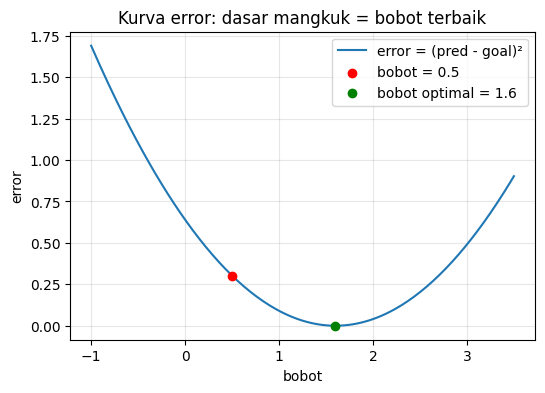

weight_delta pada bobot 0.5 = -0.275 (negatif -> bobot harus dinaikkan)


In [12]:
# Tambahan (tidak ada di buku): kurva error berbentuk mangkuk dan slope (derivative)
import numpy as np
import matplotlib.pyplot as plt

input, goal_pred = 0.5, 0.8
ws = np.linspace(-1, 3.5, 200)
errs = (input * ws - goal_pred) ** 2

w0 = 0.5
slope = input * (input * w0 - goal_pred)           # weight_delta (tanpa faktor 2)
plt.figure(figsize=(6, 4))
plt.plot(ws, errs, label='error = (pred - goal)²')
plt.scatter([w0], [(input * w0 - goal_pred) ** 2], color='red', zorder=3, label=f'bobot = {w0}')
plt.scatter([goal_pred / input], [0], color='green', zorder=3, label='bobot optimal = 1.6')
plt.xlabel('bobot'); plt.ylabel('error'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Kurva error: dasar mangkuk = bobot terbaik')
plt.show()
print('weight_delta pada bobot 0.5 =', slope, '(negatif -> bobot harus dinaikkan)')

---
## 8. Memakai *Derivative* untuk Belajar

Aturan pembaruan bobot menjadi:
$$w\leftarrow w-\alpha\cdot x\cdot(\text{pred}-\text{goal})$$
Kita dapat **memverifikasi secara numerik** bahwa `weight_delta` memang slope error terhadap bobot, dengan membandingkannya dengan perubahan error saat bobot digeser sangat sedikit.

In [13]:
weight = 0.0
goal_pred = 0.8
input = 1.1

for iteration in range(4):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = delta * input
    weight = weight - weight_delta

    print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.6400000000000001 Prediction:0.0
Error:0.02822400000000005 Prediction:0.9680000000000002
Error:0.0012446784000000064 Prediction:0.76472
Error:5.4890317439999896e-05 Prediction:0.8074088


In [14]:
# Tambahan (tidak ada di buku): verifikasi numerik derivative (beda hingga)
w, x, g = 0.3, 1.1, 0.8
def err(w): return (x * w - g) ** 2

h = 1e-6
numerik = (err(w + h) - err(w - h)) / (2 * h)        # d(error)/dw secara numerik
analitik = 2 * x * (x * w - g)                       # rumus turunan
weight_delta = x * (x * w - g)                       # versi buku (tanpa faktor 2)
print('numerik       :', round(numerik, 6))
print('analitik      :', round(analitik, 6))
print('weight_delta  :', round(weight_delta, 6), ' (= analitik / 2)')

numerik       : -1.034
analitik      : -1.034
weight_delta  : -0.517  (= analitik / 2)


**Interpretasi:** turunan numerik sama dengan rumus analitik, dan `weight_delta` buku tepat setengahnya (faktor 2 diserap oleh `alpha`).

---
## 9. Merusak *Gradient Descent*: *Overcorrection* dan *Alpha*

Jika **input besar**, `weight_delta = input × delta` ikut besar, sehingga koreksi **melampaui** titik optimal (*overcorrection*) dan error malah **membesar** (***divergence***).

In [15]:
weight = 0.5
goal_pred = 0.8
input = 0.5

for iteration in range(20):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = input * delta
    weight = weight - weight_delta
    print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.30250000000000005 Prediction:0.25
Error:0.17015625000000004 Prediction:0.3875
Error:0.095712890625 Prediction:0.49062500000000003
Error:0.05383850097656251 Prediction:0.56796875
Error:0.03028415679931642 Prediction:0.6259765625
Error:0.0170348381996155 Prediction:0.669482421875
Error:0.00958209648728372 Prediction:0.70211181640625
Error:0.005389929274097089 Prediction:0.7265838623046875
Error:0.0030318352166796153 Prediction:0.7449378967285156
Error:0.0017054073093822882 Prediction:0.7587034225463867
Error:0.0009592916115275371 Prediction:0.76902756690979
Error:0.0005396015314842384 Prediction:0.7767706751823426
Error:0.000303525861459885 Prediction:0.7825780063867569
Error:0.00017073329707118678 Prediction:0.7869335047900676
Error:9.603747960254256e-05 Prediction:0.7902001285925507
Error:5.402108227642978e-05 Prediction:0.7926500964444131
Error:3.038685878049206e-05 Prediction:0.7944875723333098
Error:1.7092608064027242e-05 Prediction:0.7958656792499823
Error:9.614592036015323

In [16]:
# Now let's break it:

weight = 0.5
goal_pred = 0.8
input = 2

for iteration in range(20):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = input * delta
    weight = weight - weight_delta
    print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.03999999999999998 Prediction:1.0
Error:0.3599999999999998 Prediction:0.20000000000000018
Error:3.2399999999999984 Prediction:2.5999999999999996
Error:29.159999999999986 Prediction:-4.599999999999999
Error:262.4399999999999 Prediction:16.999999999999996
Error:2361.959999999998 Prediction:-47.79999999999998
Error:21257.639999999978 Prediction:146.59999999999994
Error:191318.75999999983 Prediction:-436.5999999999998
Error:1721868.839999999 Prediction:1312.9999999999995
Error:15496819.559999991 Prediction:-3935.799999999999
Error:139471376.03999993 Prediction:11810.599999999997
Error:1255242384.3599997 Prediction:-35428.59999999999
Error:11297181459.239996 Prediction:106288.99999999999
Error:101674633133.15994 Prediction:-318863.79999999993
Error:915071698198.4395 Prediction:956594.5999999997
Error:8235645283785.954 Prediction:-2869780.599999999
Error:74120807554073.56 Prediction:8609344.999999996
Error:667087267986662.1 Prediction:-25828031.799999986
Error:6003785411879960.0 Predi

**Interpretasi:** dengan `input = 2`, tiap koreksi terlalu besar sehingga prediksi berayun melewati target dengan amplitudo makin besar, dan error meledak (*divergence*).

**Solusi: *alpha* (*learning rate*)**: kalikan `weight_delta` dengan angka kecil agar langkah tidak berlebihan.

In [17]:
weight = 0.5
goal_pred = 0.8
input = 2
alpha = 0.1

for iteration in range(20):
    pred  = input * weight
    error = (pred - goal_pred) ** 2
    derivative = input * (pred - goal_pred)
    weight = weight - (alpha * derivative)

    print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.03999999999999998 Prediction:1.0
Error:0.0144 Prediction:0.92
Error:0.005183999999999993 Prediction:0.872
Error:0.0018662400000000014 Prediction:0.8432000000000001
Error:0.0006718464000000028 Prediction:0.8259200000000001
Error:0.00024186470400000033 Prediction:0.815552
Error:8.70712934399997e-05 Prediction:0.8093312
Error:3.134566563839939e-05 Prediction:0.80559872
Error:1.1284439629823931e-05 Prediction:0.803359232
Error:4.062398266736526e-06 Prediction:0.8020155392
Error:1.4624633760252567e-06 Prediction:0.8012093235200001
Error:5.264868153690924e-07 Prediction:0.8007255941120001
Error:1.8953525353291194e-07 Prediction:0.8004353564672001
Error:6.82326912718715e-08 Prediction:0.8002612138803201
Error:2.456376885786678e-08 Prediction:0.8001567283281921
Error:8.842956788836216e-09 Prediction:0.8000940369969153
Error:3.1834644439835434e-09 Prediction:0.8000564221981492
Error:1.1460471998340758e-09 Prediction:0.8000338533188895
Error:4.125769919393652e-10 Prediction:0.80002031199

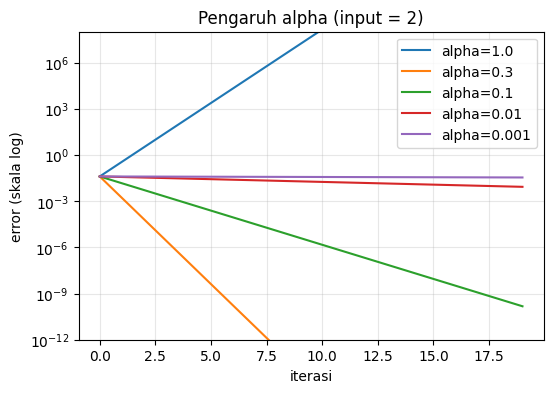

In [18]:
# Tambahan (tidak ada di buku): mencari alpha dengan membandingkan orde besaran
import matplotlib.pyplot as plt

def latih(alpha, input=2.0, goal=0.8, w=0.5, n=20):
    hist = []
    for _ in range(n):
        pred = input * w
        hist.append((pred - goal) ** 2)
        w -= alpha * input * (pred - goal)
    return hist

plt.figure(figsize=(6, 4))
for a in [1.0, 0.3, 0.1, 0.01, 0.001]:
    plt.plot(latih(a), label=f'alpha={a}')
plt.yscale('log'); plt.ylim(1e-12, 1e8)
plt.xlabel('iterasi'); plt.ylabel('error (skala log)'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Pengaruh alpha (input = 2)')
plt.show()

**Interpretasi:** `alpha=1` **diverge**; `alpha=0,3` dan `0,1` konvergen cepat; `alpha` yang terlalu kecil (`0,001`) konvergen **sangat lambat**. Praktiknya, *alpha* dicari dengan mencoba berbagai **orde besaran** (… 10, 1, 0,1, 0,01, 0,001 …) lalu memilih yang paling cepat menurunkan error tanpa divergen.

---
## 10. Ringkasan Bab

- Alur: `delta = pred - goal` → `weight_delta = delta * input` → `weight -= alpha * weight_delta`.
- `weight_delta` adalah ***derivative*** error terhadap bobot (slope kurva error).
- Input besar dapat menyebabkan ***divergence***; diatasi dengan ***alpha***.

### Rangkuman konsep
| Subbab | Konsep | Rumus/kode |
|---|---|---|
| Compare | MSE | `(pred - goal) ** 2` |
| Hot & cold | Coba naik/turun | `up_error`, `down_error` |
| Arah & besar | `delta × input` | `weight_delta = input * delta` |
| *Gradient descent* | Turun mengikuti slope | `weight -= alpha * weight_delta` |
| *Derivative* | Slope kurva error | Verifikasi numerik |
| *Overcorrection* | Input besar → divergen | Pilih *alpha* |